## Dos ejemplos más del teorema del límite central
Ingresos anuales para solicitantes de préstamos en Lending Club (https://www.lendingclub.com/). Tomaremos 3 muestras de estos datos: una muestra de 1k valores, una muestra de 1k medias de 5 valores y una muestra de 1k medias de 25 valores. 

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample 
from scipy.stats import bootstrap

In [27]:
ingresos = pd.read_csv("loans_income.csv")

In [28]:
muestra_datos = pd.DataFrame({
    'ingresos': ingresos.x.sample(1000),
    'tipo': 'Datos'
})

In [29]:
media_muestral_5 = pd.DataFrame({
    'ingresos': [ingresos.x.sample(5).values.mean() for _ in range(1000)],
    'tipo': 'Media de 5'
})

In [30]:
media_muestral_25 = pd.DataFrame({
    'ingresos': [ingresos.x.sample(25).mean() for _ in range(1000)],
    'tipo':'Media de 25'
})

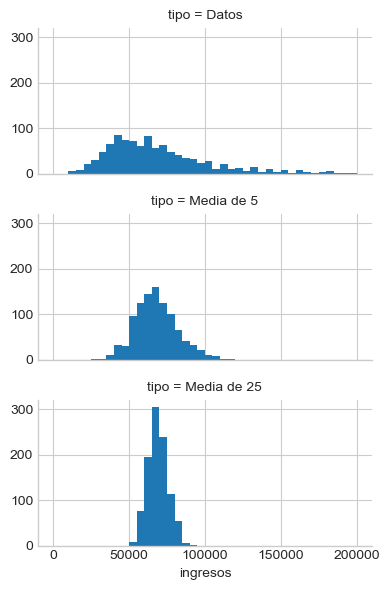

In [31]:
res = pd.concat([muestra_datos, media_muestral_5, media_muestral_25])
g = sns.FacetGrid(res, col = 'tipo', col_wrap = 1, height = 2, aspect = 2)
g.map(plt.hist, 'ingresos', range = [0, 200000], bins = 40)
plt.show()

## Intervalos de confianza para proporciones
Como ya hemos visto, como la proporción muestral $\hat{\pi}$ es la media muestral $\bar{y}$ para datos binarios (0, 1), la **distribución muestral** de la variable aleatoria $\hat{\pi}=\bar{Y}$ es **aproximadamente normal**, para $n$ grande. Esta distribución tiene media $\pi$ (la proporción real, teórica) y error estándar $\sigma_{\hat{\pi}}=\sqrt{\pi(1-\pi)/n}$. Luego, la cantidad pivotal 
$$
    Z = \frac{\hat{\pi}-\pi}{\sqrt{\frac{\pi(1-\pi)}{n}}}\text{,}
$$
tiene una distribución aproximadamente **normal estándar**. Acotando esto entre cuantiles de la distr. $N(0,1)$ obtenemos que
$$
    \mathbb{P}\left[-z_{\alpha/2}\le \frac{\hat{\pi}-\pi}{\sqrt{\frac{\pi(1-\pi)}{n}}}\le z_{\alpha/2}\right]\to1-\alpha\text{.}
$$
Para construir un intervalo de confianza para $\pi$ **después de observar** la proporción muestral $\hat{\pi}$, se resuelven las igualdades 
$$
    \hat{\pi}-\pi=\pm z_{\alpha/2}\sqrt{\frac{\pi(1-\pi)}{n}}
$$
para $\pi$ y así se obtienen los extremos del intervalo. Elevando al cuadrado ambos lados de la igualdad y resolviendo la ecuación cuadrática para $\pi$ obtenemos el siguiente intervalo de confianza
$$
    \left(\hat{\pi}+\frac{z_{\alpha/2}^2}{2n}\pm z_{\alpha/2}\sqrt{\left[\hat{\pi}(1-\hat{\pi})+z_{\alpha/2}^2/4n\right]/n}\right)\Bigg/\left(1+\frac{z_{\alpha/2}^2}{n}\right)\text{,}
$$
llamado el _intervalo de confianza score_ para una proporción. Aunque la teoría está basada en un $n$ grande, tiene buen desempeño para la mayoría de $n$ en la práctica.

La fórmula anterior es un poco intrincada, al incrementarse $n$, $z_{\alpha/2}^2/n$ tiende a 0 y el intervalo de confianza toma una forma aproximada sencilla
$$
    \hat{\pi}\pm z_{\alpha/2}\sqrt{\frac{\hat{\pi}(1-\hat{\pi})}{n}}\text{,}
$$
la cual tiene una forma familiar, 
$$
    \hat{\theta}\pm z_{\alpha/2}\sigma_{\hat{\theta}}\text{,}
$$
sustituyendo un error estándar **estimado** en lugar del verdadero. Este método de construcción de intervalos de confianza, sumando y restando un múltiplo de un error estándar estimado, es llamado **intervalo de confianza de Wald**. La forma simple de este intervalo es atractiva, sin embargo, no tiene el mismo desempeño que el intervalo de confianza score. 

Un aspecto que se destaca de la fórmula para el intervalo de confianza score es que en el cálculo del punto medio del intervalo
$$
    \left(\hat{\pi}+\frac{z_{\alpha/2}^2}{2n}\right)\Bigg/\left(1+\frac{z_{\alpha/2}^2}{n}\right) = \hat{\pi}\left(\frac{n}{n+z_{\alpha/2}^2}\right)+\frac{1}{2}\left(\frac{z_{\alpha/2}^2}{n+z_{\alpha/2}^2}\right)\text{,}
$$
el cual es un promedio ponderado de el valor estimado $\hat{\pi}$ y $1/2$, lo cual tiene un efecto de shrinkage sobre $\hat{\pi}$.

Ejemplo: Ateos y agnósticos en Europa.

Una encuesta de 2019 realizada por Eurobarometer (https://europa.eu/eurobarometer/screen/home) reportó que el porcentaje de personas que son ate@s o agnóstic@s varía en Europa Occidental entre 9% en Irlanda y 52% en Países Bajos (entre otros). Los intervalos de confianza nos muestran la precisión de estos estimados. Veamos el caso de Países Bajos, con $n=1497$ encuestados y $778$ que reportaron ser ate@s o agnóstic@s. 

In [32]:
from statsmodels.stats.proportion import proportion_confint

In [33]:
proportion_confint(778, 1497, method = 'normal')    # intervalo de confianza default de Wald de 95%

(0.4943973906940667, 0.545014766954564)

In [34]:
proportion_confint(778, 1497, method = 'wilson')    # intervalo de confianza score de 95%

(0.4943793119474541, 0.5449319688365669)

## Función de distribución empírica
Algunos métodos de inferencia suponen que los datos vienen de una familia de distribuciones. Otros métodos, como el bootstrap, no hacen esa suposición. Cuando la _función de distribución acumulada_ ($F(x)$) es completamente desconocida, el estimador natural es su **_función de distribución acumulada empírica_**.
> ### **Función de distribución acumulada empírica**
> Para vars. aleat. independientes provenientes de una distribución particular, $Y_1,...,Y_n$, la _función de distribución acumulada empírica_ es
> $$
 F_n(y)=\frac{1}{n}\sum_{i=1}^n\mathbb{1}(Y_i\le y)\text{,}
 $$
> donde $\mathbb{1}(\cdot)$ es la función indicadora
> $$
 \mathbb{1}(Y_i\le y)=\begin{cases} 1,\ &\text{si}\ Y_i\le y\\
 0,\ &\text{c.o.c.}
 \end{cases}
 $$

Es decir, $F_n(y)$ es la proporción muestral de las $n$ observaciones que caen antes de, o en, $y$.

Ejemplo:

In [35]:
from scipy.stats import ecdf, norm

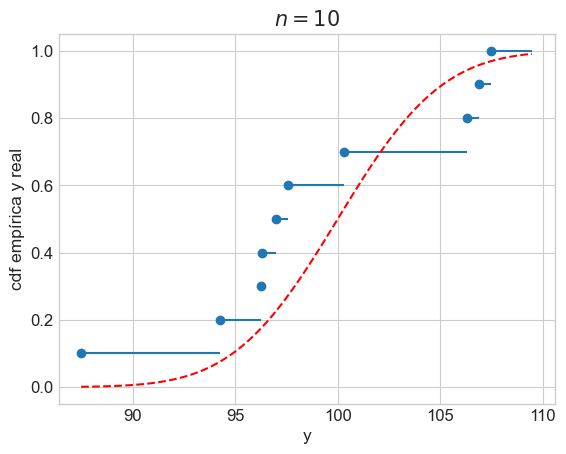

In [36]:
plt.style.use('seaborn-v0_8-whitegrid')
x = np.sort(np.random.normal(100, 4, 10))
xmin = x
xmax = np.append(x[1:], x[-1]+0.1*(x[-1]-x[0]))
emp_distr_f = ecdf(x)
y = emp_distr_f.cdf.evaluate(xmin)
plt.hlines(y, xmin, xmax)
plt.scatter(x, emp_distr_f.cdf.evaluate(x))
dom = np.linspace(x[0], xmax[-1], 100)
plt.plot(dom, norm.cdf(dom, loc = 100, scale = 4), '--', color = 'red')
plt.xlabel('y', fontsize = 12.5)
plt.ylabel('cdf empírica y real', fontsize = 12.5)
plt.title(r'$n=10$', fontsize = 15)
plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)
plt.show()

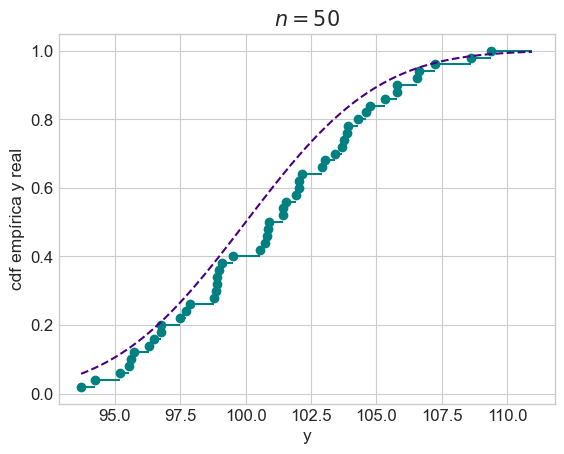

In [37]:
plt.style.use('seaborn-v0_8-whitegrid')
x = np.sort(np.random.normal(100, 4, 50))
xmin = x
xmax = np.append(x[1:], x[-1]+0.1*(x[-1]-x[0]))
emp_distr_f = ecdf(x)
y = emp_distr_f.cdf.evaluate(xmin)
plt.hlines(y, xmin, xmax, color = 'teal')
plt.scatter(x, emp_distr_f.cdf.evaluate(x), color = 'teal')
dom = np.linspace(x[0], xmax[-1], 100)
plt.plot(dom, norm.cdf(dom, loc = 100, scale = 4), '--', color = 'indigo')
plt.xlabel('y', fontsize = 12.5)
plt.ylabel('cdf empírica y real', fontsize = 12.5)
plt.title(r'$n=50$', fontsize = 15)
plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)
plt.show()

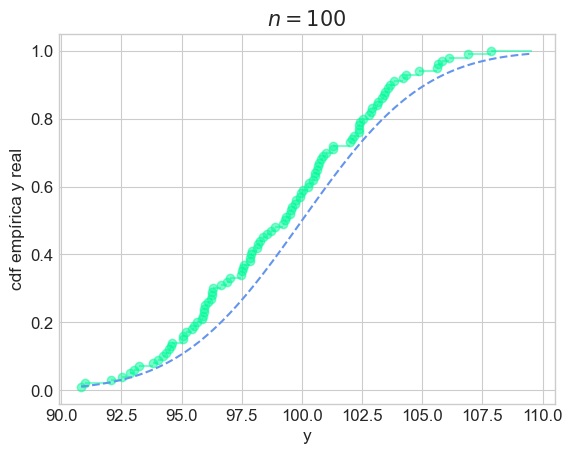

In [38]:
plt.style.use('seaborn-v0_8-whitegrid')
x = np.sort(np.random.normal(100, 4, 100))
xmin = x
xmax = np.append(x[1:], x[-1]+0.1*(x[-1]-x[0]))
emp_distr_f = ecdf(x)
y = emp_distr_f.cdf.evaluate(xmin)
plt.hlines(y, xmin, xmax, color = 'mediumspringgreen', alpha = 0.5)
plt.scatter(x, emp_distr_f.cdf.evaluate(x), color = 'mediumspringgreen', alpha = 0.5)
dom = np.linspace(x[0], xmax[-1], 100)
plt.plot(dom, norm.cdf(dom, loc = 100, scale = 4), '--', color = 'cornflowerblue')
plt.xlabel('y', fontsize = 12.5)
plt.ylabel('cdf empírica y real', fontsize = 12.5)
plt.title(r'$n=100$', fontsize = 15)
plt.yticks(fontsize = 12)
plt.xticks(fontsize = 12)
plt.show()

La _cdf_ empírica es la _cdf_ de la distribución discreta que asigna una probabilidad $1/n$ a cada observación, por lo que es una función escalonada. Al incrementarse $n$ la _cdf_ empírica converge uniformemente sobre $y$ a la verdaddera _cdf_ subyacente. Este resultado es llamado el _Teorema de Glivenko-Cantelli_.

## Bootstrap
Muchos estadísticos son muy complejos como para contar con una fórmula simple de error estándar. Este es el caso generalmente para estadísticos desarrollados _ad hoc_. Una forma fácil y efectiva de estimar la distribución muestral de un estadístico es obtener más muestras, con reemplazo, de la muestra misma y recalcular el estadístico para cada remuestreo. Este procedimiento es conocido como _bootstrap_ y no necesariamente involucra alguna suposición de normalidad sobre los datos o el estadístico. En este método se trata a la distribución de la muestra como si fuera la verdadera distirbución poblacional y aproxima características de la distribución muestral desconocida por simulación.

Conceptualmente, se puede imaginar al bootstrap como replicar la muestra original miles o millones de veces tal que se tenga una **población hipotética** que contenga toda la información disponible de la muestra original. Luego entonces, se pueden extraer muestras de esta población hipotética con el propósito de estimar una distribución muestral.
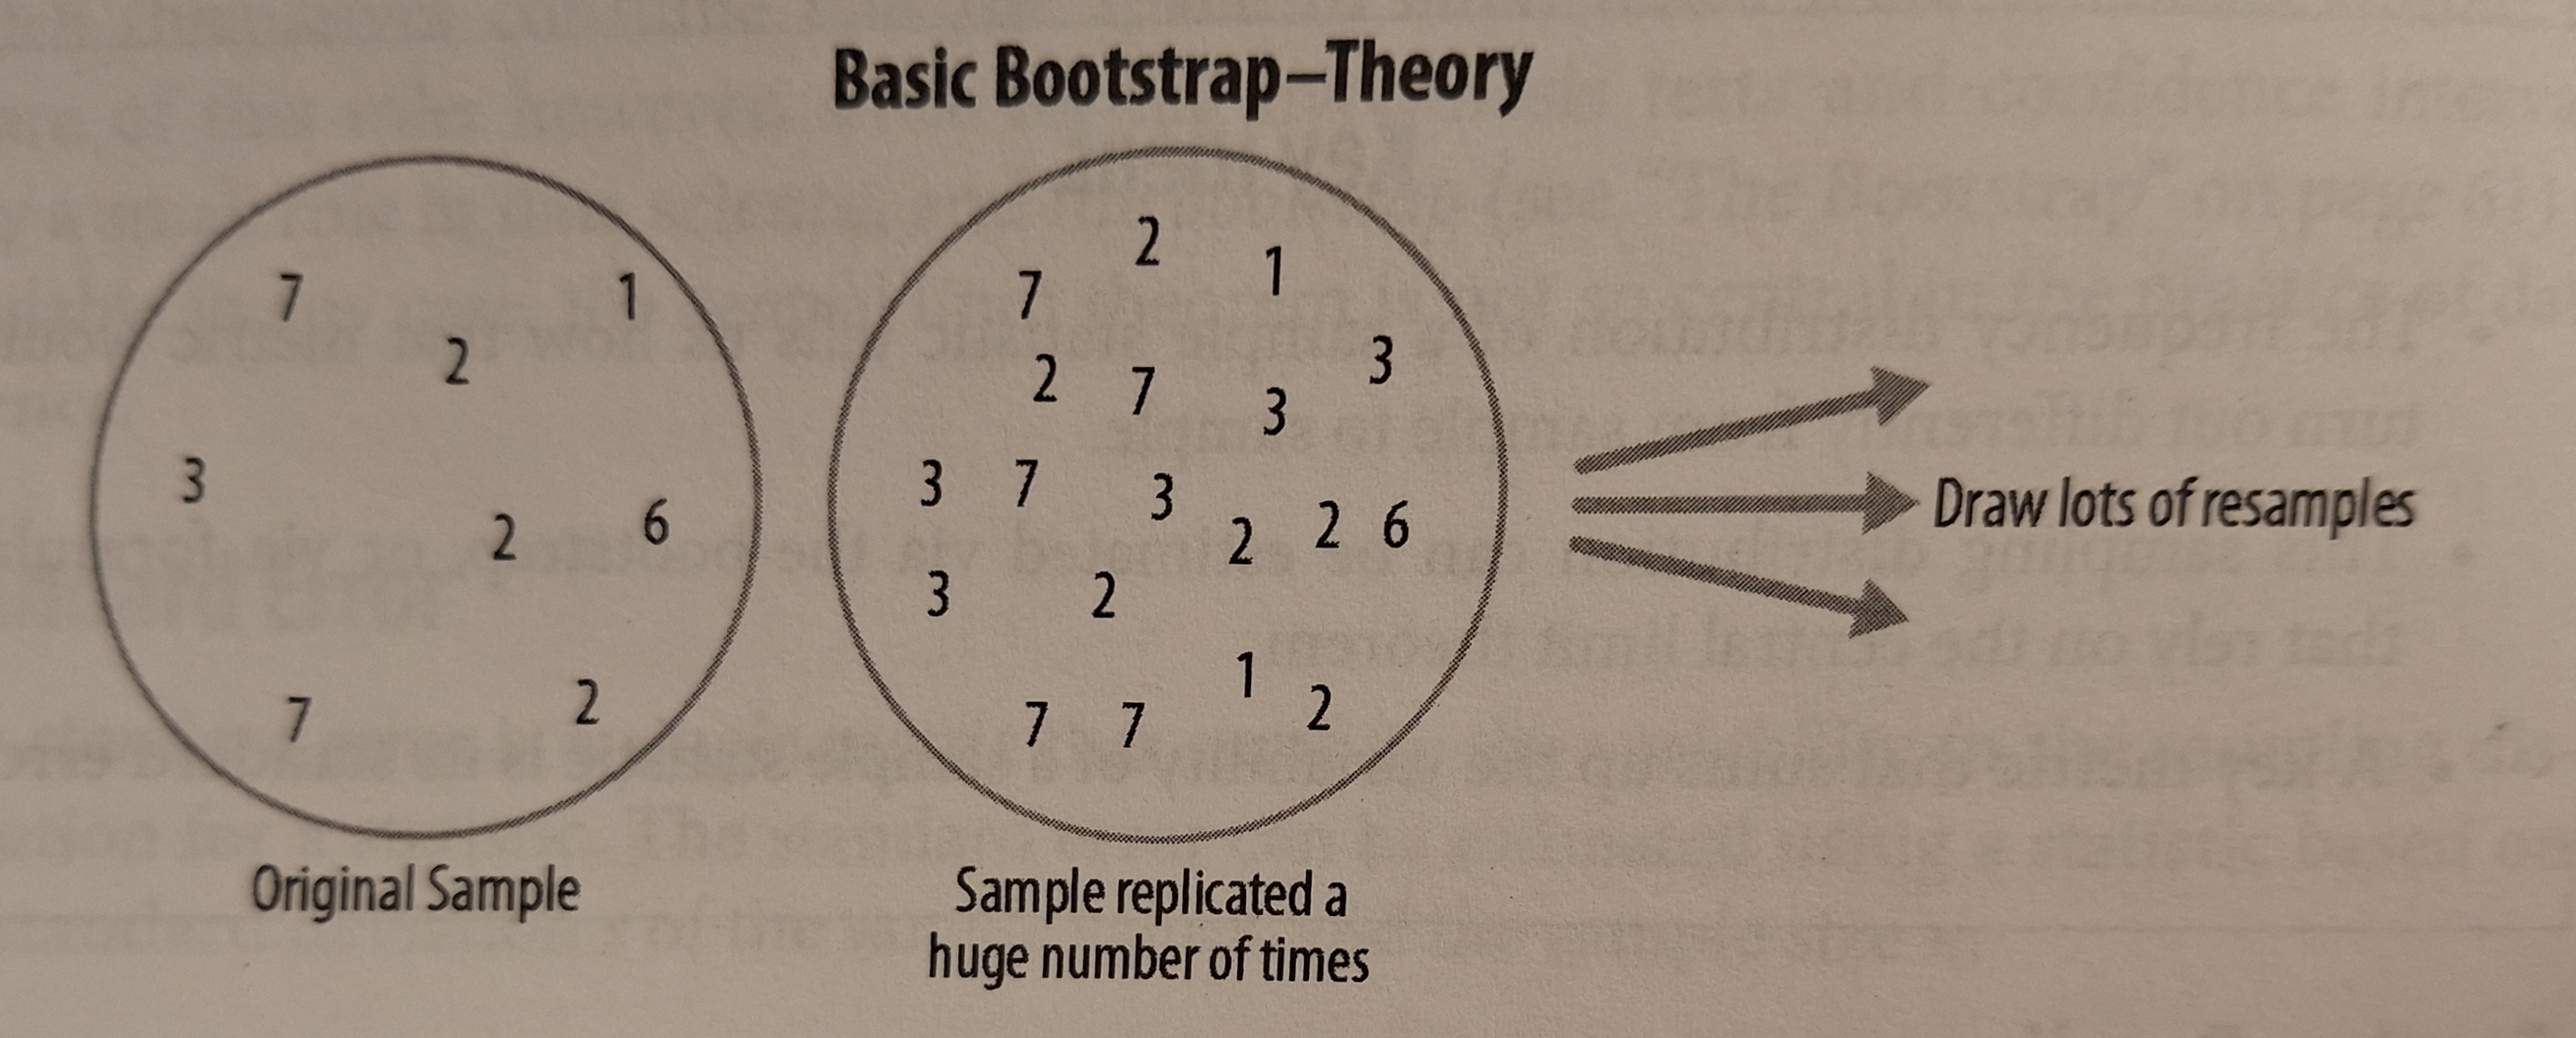

Ciertamente en la práctica no es necesario replicar la muestra un gran número de veces. Simplemente reemplazamos cada observación después de cada extracción, efectivamente creando una "población infinita" en donde la probabilidad de que cada elemento sea muestreado permanece inalterada.

El algoritmo para un remuestreo bootstrap de la media, para una muestra de tamaño $n$, es el siguiente:
1. Extrae un valor de la muestra, regístralo y regrésalo.
2. Repetir el paso anterior $n$ veces.
3. Registrar la media de los $n$ datos remuestrados.
4. Repetir los pasos 1-3 $N$ veces.
5. Usar los resultados para:
     - Calcular su desviación estándar (estimar el error estándar de la media muestral).
     - Producir un histograma o boxplot.
     - Encontrar un intervalo de confianza.

Cada uno de los $n$ datos originales tiene probabilidad $1/n$ de ser seleccionado para cada "nueva" observación. Y cada muestra de tamaño $n$ tiene su propio valor/estimado de $\theta$ (en el algoritmo, la media). La distribución bootstrap tiene forma y variabilidad parecida a la verdadera distribución muestral de $\hat{\theta}$ alrededor de $\theta$, pero en este caso varía alrededor de $\hat{\theta}$ (el valor obtenido en un principio), en lugar de $\theta$. Es decir, la distribución muestral bootstrap de $\hat{\theta}^{(b)}-\hat{\theta}$ es similar a la distribución muestral (original, real) de $\hat{\theta}-\theta$. Es por esto que la desviación estándar de los valores simulados $\{\hat{\theta}^{(b)}\}$ estima el error estándar del estimador puntual $\hat{\theta}$ de los datos observados.

### Ejercicio: Intervalos de confianza para datos de biblioteca
Una bibliotecaria en la Universidad de Florida quiso estimar varias características de los libros en una de las colecciones especiales de la universidad. Entre las preguntas de interés fueron "¿Qué tan antiguo es un libro típico en la colección?" y "¿Cuánto ha pasado desde que un libro típico ha sido consultado?". Ella sospechó que las distribuciones de estas variables son fuertemente sesgadas a la derecha, así que escogió la mediana para describir el centro. En el archivo _biblio.csv_ se tienen observaciones de $P=$ nro. de años desde publicación y $C=$ número de años desde que fue consultado el libro, para una muestra aleatoria simple de 54 libros de la colección.
 - Construye un boxplot de los valores de P y comenta qué observas.
 - Utiliza bootstrap para estimar la desviación estándar de la mediana muestral así como para construir un intervalo de confianza para la mediana poblacional.
 - Construye un intervalo de confianza para la desviación estándar $\sigma$ poblacional del nro. de años desde la publicación del libro.
 - Finalmente utiliza bootstrap para crear un histograma de la distribución de la correlación muestral. 

Para lo anterior utiliza alguna de las funciones siguientes:

La anterior de la paquetería scikit learn, observa de la documentación que ya está indicado que el remuestreo se haga **con reemplazo**. O también puedes intentar con

En donde al argumento _statistic_ le pasas lo que deseas calcular (mediana, desv. estándar, coef. de corr.)

En ambos casos piensa si necesitas muestrear una variable o ambas.

## Solución

In [39]:
biblio = pd.read_csv('biblio.csv')
biblio.head()

,C,P
0,1,3
1,9,9
2,4,4
3,1,18
4,1,5


<Axes: xlabel='P'>

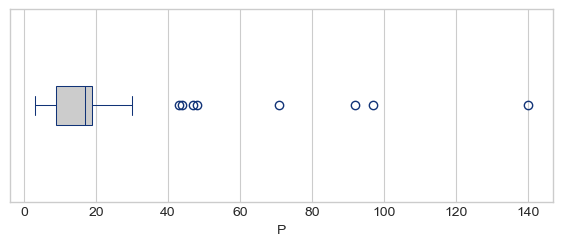

In [40]:
plt.figure(figsize = (7, 2.5))
ax = plt.subplot(111)
sns.boxplot(x = biblio['P'], width = .2, ax = ax, color = ".8", linecolor="#137", linewidth=.75)

In [41]:
np.median(biblio.P.values)    # Mediana poblacional "original"

np.float64(17.0)

In [42]:
n = 10000
muestras = np.empty((n,np.shape(biblio.P.values)[0]))
for i in range(0,n):
    muestras[i,:] = resample(biblio.P.values)

In [43]:
medianas = np.median(muestras, axis = 1)
np.std(medianas)    # Desv. est. estimada para la mediana muestral

np.float64(2.277535402578849)

In [44]:
np.quantile(medianas, (0.025,0.975))    # Intervalo de confianza del 95%, sin asumir distribución

array([11., 19.])

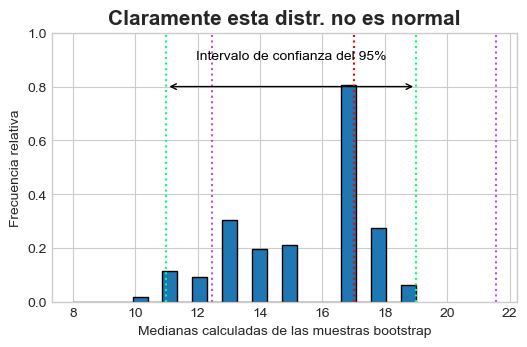

In [45]:
plt.figure(figsize = (6, 3.5))
plt.hist(medianas, bins = 23, edgecolor = 'k', density = True)
plt.vlines(17.0, 0.0, 1, linestyles = 'dotted', colors = 'red')
plt.vlines(17.0-2*(np.std(medianas)), 0.0, 1, linestyles = 'dotted', colors = 'mediumorchid')
plt.vlines(17.0+2*(np.std(medianas)), 0.0, 1, linestyles = 'dotted', colors = 'mediumorchid')
plt.vlines(11, 0.0, 1, linestyles = 'dotted', colors = 'springgreen')
plt.vlines(19, 0.0, 1, linestyles = 'dotted', colors = 'springgreen')
plt.ylim(0,1)
plt.annotate('', xy=(11, 0.8),
              xytext=(19, 0.8), arrowprops=dict(arrowstyle='<->', color='k',))
plt.annotate('Intervalo de confianza del 95%', xy =(12,0.9),
xytext = (15, 0.9), fontsize = 10, color = 'k', ha = 'center')
plt.xlabel('Medianas calculadas de las muestras bootstrap')
plt.ylabel('Frecuencia relativa')
plt.title('Claramente esta distr. no es normal', weight = 'bold', fontsize = 15)
plt.show()

In [46]:
btstrp = bootstrap((biblio.P.values,), statistic = np.median)

In [47]:
btstrp.confidence_interval

ConfidenceInterval(low=np.float64(13.0), high=np.float64(19.0))

In [48]:
btstrp.standard_error

np.float64(2.23892836862101)

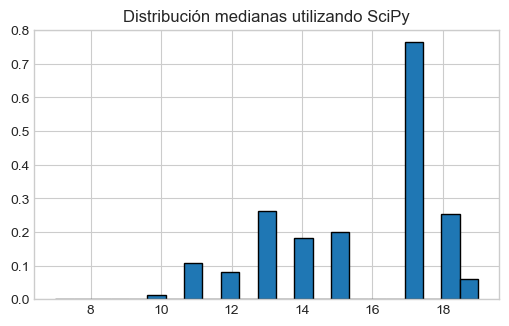

In [49]:
plt.figure(figsize = (6, 3.5))
plt.hist(btstrp.bootstrap_distribution, bins = 23, edgecolor = 'k', density = True)
plt.title('Distribución medianas utilizando SciPy')
plt.show()

In [50]:
np.std(biblio.P.values)    # sigma estimada "original"

np.float64(25.548688675899356)

In [51]:
boot = bootstrap((biblio.P.values,), statistic = np.std, method = 'BCa')
boot.confidence_interval

ConfidenceInterval(low=np.float64(16.15416953367526), high=np.float64(40.07937612853402))

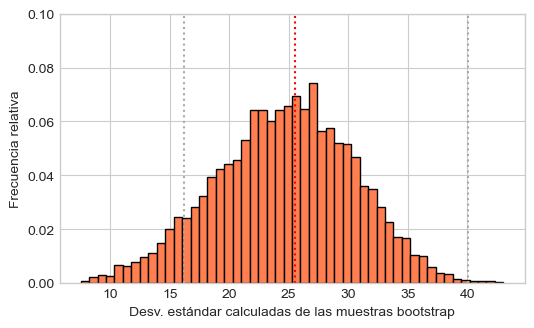

In [52]:
ci = np.array(boot.confidence_interval)
plt.figure(figsize = (6, 3.5))
plt.hist(boot.bootstrap_distribution, bins = 50, color = 'coral', edgecolor = 'k', density = True)
plt.vlines(25.548, 0.0, 0.1, linestyles = 'dotted', colors = 'red')
plt.vlines(ci[0], 0.0, 0.1, linestyles = 'dotted', colors = 'darkgrey')
plt.vlines(ci[1], 0.0, 0.1, linestyles = 'dotted', colors = 'darkgrey')
plt.ylim(0,0.1)
plt.xlabel('Desv. estándar calculadas de las muestras bootstrap')
plt.ylabel('Frecuencia relativa')
plt.show()

In [53]:
np.corrcoef(biblio.P.values, biblio.C.values)[0,1]

np.float64(0.8121555062071949)

In [54]:
def corr(x, y):
    return np.corrcoef(x, y)[0,1]

In [55]:
from scipy.stats import pearsonr
def my_statistic(x, y, axis=-1):
    return pearsonr(x, y, axis=axis)[0]

In [56]:
botitas = bootstrap((biblio.P.values, biblio.C.values), my_statistic, paired=True)
print(botitas.confidence_interval)

ConfidenceInterval(low=np.float64(0.5839208401178975), high=np.float64(0.9130948365965412))


In [57]:
botitas = bootstrap((biblio.P.values, biblio.C.values), corr, paired=True)
print(botitas.confidence_interval)

ConfidenceInterval(low=np.float64(0.5974144228222806), high=np.float64(0.9137205614038146))


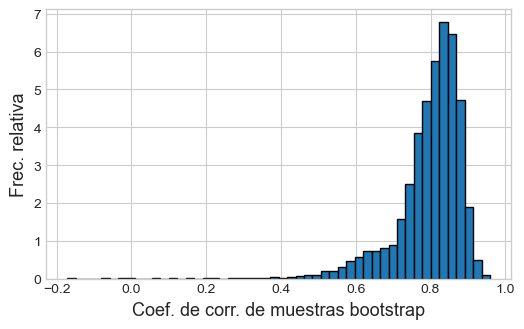

In [58]:
plt.figure(figsize = (6, 3.5))
plt.hist(botitas.bootstrap_distribution, edgecolor = 'k', bins = 50, density = True)
plt.xlabel('Coef. de corr. de muestras bootstrap', fontsize = 13)
plt.ylabel('Frec. relativa', fontsize = 13)
plt.show()

In [59]:
import platform
print(platform.python_version())

3.13.1
